In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import os
import joblib
from mlflow.tracking import MlflowClient
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, validation_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay

In [2]:
df_students = pd.read_excel('../data/StudentsPrepared.xlsx')
df_students.head(10)

,EstadoCivil,Curso,QualificacaoAnterior,QualificacaoAnteriorGrau,Nacionalidade,NotaAdmissao,NecessidadesEspeciais,Devedor,MensalidadesEmDia,Genero,...,UnidadesCurriculares2SemestreCreditado,UnidadesCurriculares2SemestreInscrito,UnidadesCurriculares2SemestreAvaliacoes,UnidadesCurriculares2SemestreAprovado,UnidadesCurriculares2SemestreGrau,UnidadesCurriculares2SemestreSemAvaliacoes,TaxaDesemprego,TaxaInflacao,PIB,Target
0,Solteiro,Design de Animação e Multimédia,Ensino Secundário,122.0,Português,127.3,0,0,1,Masculino,...,0,0,0,0,0.000000e+00,0,10.8,1.4,1.74,Desistente
1,Solteiro,Turismo,Ensino Secundário,160.0,Português,142.5,0,0,0,Masculino,...,0,6,6,6,1.366667e+16,0,13.9,-0.3,0.79,Graduado
2,Solteiro,Design de Comunicação,Ensino Secundário,122.0,Português,124.8,0,0,0,Masculino,...,0,6,0,0,0.000000e+00,0,10.8,1.4,1.74,Desistente
3,Solteiro,Jornalismo e Comunicação,Ensino Secundário,122.0,Português,119.6,0,0,1,Feminino,...,0,6,10,5,1.240000e+01,0,9.4,-0.8,-3.12,Graduado
4,Casado,Serviço Social (prestação nocturna),Ensino Secundário,100.0,Português,141.5,0,0,1,Feminino,...,0,6,6,6,1.300000e+01,0,13.9,-0.3,0.79,Graduado
5,Casado,Gestão (presencial noturno),Ensino Básico (3º Ciclo),133.1,Português,114.8,0,1,1,Masculino,...,0,5,17,5,1.150000e+01,5,16.2,0.3,-0.92,Graduado
6,Solteiro,Enfermagem,Ensino Secundário,142.0,Português,128.4,0,0,1,Feminino,...,0,8,8,8,1.434500e+04,0,15.5,2.8,-4.06,Graduado
7,Solteiro,Turismo,Ensino Secundário,119.0,Português,113.1,0,0,0,Masculino,...,0,5,5,0,0.000000e+00,0,15.5,2.8,-4.06,Desistente
8,Solteiro,Serviço Social,Ensino Secundário,137.0,Romeno,129.3,0,0,1,Feminino,...,0,6,7,6,1.414286e+16,0,16.2,0.3,-0.92,Graduado
9,Solteiro,Serviço Social,Ensino Secundário,138.0,Português,123.0,0,1,0,Feminino,...,0,6,14,2,1.350000e+01,0,8.9,1.4,3.51,Desistente


Analisando o documento XLSX, encontramos valores fora do comum nas colunas UnidadesCurriculares1SemestreGrau e UnidadesCurriculares2SemestreGrau.

Ao inspecionar a célula bruta, confirmamos que não é um erro de formatação/exibição do Excel — o valor gigante
está mesmo gravado na planilha, provavelmente por um bug na etapa de export dos dados.

Além disso, os valores anômalos não seguem uma única escala: a maioria está multiplicada por ~1e15, mas um subgrupo menor está multiplicado por ~1e3.

Por isso, em vez de dividir por um fator fixo, aplicamos um loop que divide por 10 repetidamente até o valor cair dentro da faixa esperada (0 a 20).

In [3]:
print(f'min: 1Semestre', min(df_students['UnidadesCurriculares1SemestreGrau']))
print(f'min 2Semestre: ', min(df_students['UnidadesCurriculares2SemestreGrau']))

print(f'max: 1Semestre', max(df_students['UnidadesCurriculares1SemestreGrau']))
print(f'max 2Semestre: ', max(df_students['UnidadesCurriculares2SemestreGrau']))

print('--------------------------------')

c_1_semestre_grau = df_students['UnidadesCurriculares1SemestreGrau']
while (c_1_semestre_grau > 20).any():
	c_1_semestre_grau = c_1_semestre_grau.where(
		c_1_semestre_grau <= 20, c_1_semestre_grau/10)
df_students['UnidadesCurriculares1SemestreGrau'] = c_1_semestre_grau


c_2_semestre_grau = df_students['UnidadesCurriculares2SemestreGrau']
while (c_2_semestre_grau > 20).any():
	c_2_semestre_grau = c_2_semestre_grau.where(
		c_2_semestre_grau <= 20, c_2_semestre_grau/10)
df_students['UnidadesCurriculares2SemestreGrau'] = c_2_semestre_grau

print(f'min: 1Semestre', min(df_students['UnidadesCurriculares1SemestreGrau']))
print(f'min 2Semestre: ', min(df_students['UnidadesCurriculares2SemestreGrau']))

print(f'max: 1Semestre', max(df_students['UnidadesCurriculares1SemestreGrau']))
print(f'max 2Semestre: ', max(df_students['UnidadesCurriculares2SemestreGrau']))

print('--------------------------------')

min: 1Semestre 0.0
min 2Semestre:  0.0
max: 1Semestre 1.73333333333333e+16
max 2Semestre:  1.85714285714285e+16
--------------------------------
min: 1Semestre 0.0
min 2Semestre:  0.0
max: 1Semestre 18.875
max 2Semestre:  18.571428571428502
--------------------------------


# Vamos fazer algumas verificações no DataFrame para nos preparar para o feature engineer

<Axes: title={'center': 'Target Distribution'}, xlabel='Target'>

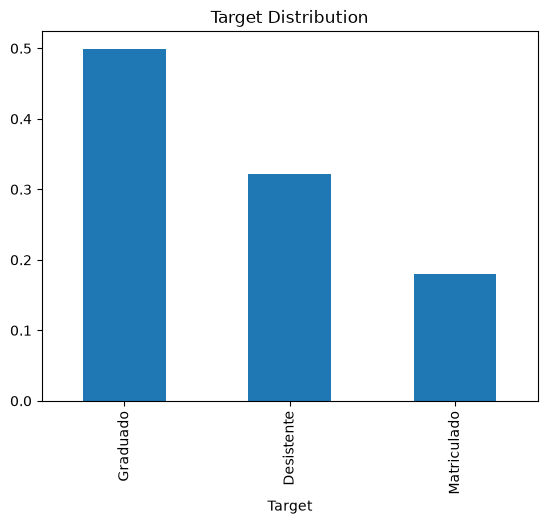

In [4]:
#Verificando a distribuição da variável alvo
df_students['Target'].value_counts(normalize=True).plot(kind='bar', title='Target Distribution')

In [5]:
#Verificando possíveis valores nulos existentes no dataset
print(df_students.isna().sum())

EstadoCivil                                   0
Curso                                         0
QualificacaoAnterior                          0
QualificacaoAnteriorGrau                      0
Nacionalidade                                 0
NotaAdmissao                                  0
NecessidadesEspeciais                         0
Devedor                                       0
MensalidadesEmDia                             0
Genero                                        0
Bolsista                                      0
International                                 0
UnidadesCurriculares1SemestreCreditado        0
UnidadesCurriculares1SemestreInscrito         0
UnidadesCurriculares1SemestreAvaliacoes       0
UnidadesCurriculares1SemestreAprovado         0
UnidadesCurriculares1SemestreGrau             0
UnidadesCurriculares1SemestreSemAvaliacoes    0
UnidadesCurriculares2SemestreCreditado        0
UnidadesCurriculares2SemestreInscrito         0
UnidadesCurriculares2SemestreAvaliacoes 

In [6]:
#Verificando os tipos de dados das colunas do dataset
df_students.dtypes

EstadoCivil                                    object
Curso                                          object
QualificacaoAnterior                           object
QualificacaoAnteriorGrau                      float64
Nacionalidade                                  object
NotaAdmissao                                  float64
NecessidadesEspeciais                           int64
Devedor                                         int64
MensalidadesEmDia                               int64
Genero                                         object
Bolsista                                        int64
International                                   int64
UnidadesCurriculares1SemestreCreditado          int64
UnidadesCurriculares1SemestreInscrito           int64
UnidadesCurriculares1SemestreAvaliacoes         int64
UnidadesCurriculares1SemestreAprovado           int64
UnidadesCurriculares1SemestreGrau             float64
UnidadesCurriculares1SemestreSemAvaliacoes      int64
UnidadesCurriculares2Semestr

In [7]:
df_students.select_dtypes(include='object').nunique()

EstadoCivil              6
Curso                   17
QualificacaoAnterior    16
Nacionalidade           21
Genero                   2
Target                   3
dtype: int64

# DataFrame ok, vamos separa-lo e iniciar o feature engineer

In [8]:
# Separamos os alunos matriculados que ainda não possuem um desfecho dos que já possuem um desfecho (graduado ou desistente)

df_enrolled = df_students[df_students['Target'] == 'Matriculado']
df_outcomes = df_students[df_students['Target'] != 'Matriculado']
df_enrolled.shape, df_outcomes.shape

((794, 28), (3630, 28))

In [9]:
target_map = {'Desistente': 1, 'Graduado': 0}
df_outcomes['Target'] = df_outcomes['Target'].map(target_map)

/var/folders/7l/cxnynkhd1g328g8l_xl_rhzh0000gn/T/ipykernel_8185/4101240697.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_outcomes['Target'] = df_outcomes['Target'].map(target_map)


In [10]:
df_outcomes['Target'].value_counts(normalize=True)

Target
0    0.60854
1    0.39146
Name: proportion, dtype: float64

In [11]:
# Vamos separar as colunas com dados categóricos das colunas com dados numéricos para facilitar os transformers.
# imputer+scaler pras numéricas, imputer+encoder pras categóricas.

categorical_cols = [
    'EstadoCivil',
    'Curso',
    'QualificacaoAnterior',
    'Nacionalidade',
    'Genero'
]

numeric_cols = [
    'QualificacaoAnteriorGrau',
    'NotaAdmissao',
    'NecessidadesEspeciais',
    'Devedor',
    'MensalidadesEmDia',
    'Bolsista',
    'International',
    'UnidadesCurriculares1SemestreCreditado',
    'UnidadesCurriculares1SemestreInscrito',
    'UnidadesCurriculares1SemestreAvaliacoes',
    'UnidadesCurriculares1SemestreAprovado',
    'UnidadesCurriculares1SemestreGrau',
    'UnidadesCurriculares1SemestreSemAvaliacoes',
    'UnidadesCurriculares2SemestreCreditado',
    'UnidadesCurriculares2SemestreInscrito',
    'UnidadesCurriculares2SemestreAvaliacoes',
    'UnidadesCurriculares2SemestreAprovado',
    'UnidadesCurriculares2SemestreGrau',
    'UnidadesCurriculares2SemestreSemAvaliacoes',
    'TaxaDesemprego',
    'TaxaInflacao',
    'PIB'
]

In [12]:
# Tem gente que nem chegou a se inscrever em nenhuma matéria no ano — aí a taxa de
# aprovação vira 0/0, que é indefinido. Pra não confundir esse pessoal com quem
# reprovou em tudo, criamos uma flag separada pra marcar eles e então preenchemos a taxa com 0.
# Também aproveitamos pra ver se o aluno melhorou ou piorou do 1º pro 2º semestre.


def add_academic_performance_features(df, numeric_cols):
    df = df.copy()

    df['no_courses_full_year'] = (
        (df['UnidadesCurriculares1SemestreInscrito'] == 0) &
        (df['UnidadesCurriculares2SemestreInscrito'] == 0)
    ).astype(int)

    df['approval_rate_sem1'] = (
        df['UnidadesCurriculares1SemestreAprovado'] / df['UnidadesCurriculares1SemestreInscrito']
    ).fillna(0)

    df['approval_rate_sem2'] = (
        df['UnidadesCurriculares2SemestreAprovado'] / df['UnidadesCurriculares2SemestreInscrito']
    ).fillna(0)

    df['grade_delta'] = df['UnidadesCurriculares2SemestreGrau'] - df['UnidadesCurriculares1SemestreGrau']
    df['approval_rate_delta'] = df['approval_rate_sem2'] - df['approval_rate_sem1']

    new_cols = [
        'no_courses_full_year',
        'approval_rate_sem1',
        'approval_rate_sem2',
        'grade_delta',
        'approval_rate_delta',
    ]
    numeric_cols.extend([col for col in new_cols if col not in numeric_cols])

    return df

In [13]:
def build_pipeline(numeric_cols, categorical_cols):
    numeric_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    return ColumnTransformer(transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ])

In [14]:
df_featured = add_academic_performance_features(df_outcomes, numeric_cols)
df_featured[['no_courses_full_year', 'approval_rate_sem1', 'approval_rate_sem2', 'grade_delta', 'approval_rate_delta']].describe()

,no_courses_full_year,approval_rate_sem1,approval_rate_sem2,grade_delta,approval_rate_delta
count,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000
mean,0.041873,0.699966,0.662755,-0.498705,-0.037211
std,0.200327,0.378162,0.400434,2.954093,0.176821
min,0.000000,0.000000,0.000000,-16.142857,-1.000000
25%,0.000000,0.500000,0.333333,-0.533333,0.000000
50%,0.000000,0.857143,0.857143,0.000000,0.000000
75%,0.000000,1.000000,1.000000,0.400000,0.000000
max,1.000000,1.000000,1.000000,14.500000,1.000000


# Feature Engineer completa, vamos ao split dos dados.

In [15]:
X = df_featured.drop(columns=['Target'])
y = df_featured['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2904, 32), (726, 32), (2904,), (726,))

# Treinamento com CV

In [16]:
# Pipelines

pipeline_logregr = Pipeline(steps=[
	('preprocessor', build_pipeline(numeric_cols, categorical_cols)),
	('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_rf = Pipeline(steps=[
	('preprocessor', build_pipeline(numeric_cols, categorical_cols)),
	('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline_xgb = Pipeline(steps=[
	('preprocessor', build_pipeline(numeric_cols, categorical_cols)),
	('classifier', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'))
])



In [17]:
stratkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

pipelines = {
	'Logistic Regression': pipeline_logregr,
	'Random Forest': pipeline_rf,
	'XGBoost': pipeline_xgb
}

stratified_results = {}

for name, pipeline in pipelines.items():
	stratified_results[name] = cross_validate(pipeline, X_train, y_train, cv=stratkf, scoring=scoring, return_train_score=True, n_jobs=-1)

In [18]:
# Testar com class_weight='balanced' para Logistic Regression e Random Forest, e scale_pos_weight para XGBoost a fim de lidar com o desbalanceamento leve.

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

pipeline_logregr_balanced = Pipeline(steps=[
	('preprocessor', build_pipeline(numeric_cols, categorical_cols)),
	('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

pipeline_rf_balanced = Pipeline(steps=[
	('preprocessor', build_pipeline(numeric_cols, categorical_cols)),
	('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

pipeline_xgb_balanced = Pipeline(steps=[
	('preprocessor', build_pipeline(numeric_cols, categorical_cols)),
	('classifier', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight))
])

pipelines_balanced = {
	'Logistic Regression (balanced)': pipeline_logregr_balanced,
	'Random Forest (balanced)': pipeline_rf_balanced,
	'XGBoost (balanced)': pipeline_xgb_balanced
}

for name, pipeline in pipelines_balanced.items():
    stratified_results[name] = cross_validate(pipeline, X_train, y_train, cv=stratkf, scoring=scoring, return_train_score=True, n_jobs=-1)



In [19]:
rows = []

for name, result in stratified_results.items():
    for metric in scoring:
        rows.append({
			'model': name,
			'metric': metric,
			'train_mean': result[f'train_{metric}'].mean(),
			'train_std': result[f'train_{metric}'].std(),
			'test_mean': result[f'test_{metric}'].mean(),
			'test_std': result[f'test_{metric}'].std()
		})

df_results = pd.DataFrame(rows)
df_results

,model,metric,train_mean,train_std,test_mean,test_std
0,Logistic Regression,accuracy,0.918216,2.815213e-03,0.908745,0.004257
1,Logistic Regression,precision,0.941849,4.430687e-03,0.924325,0.008104
2,Logistic Regression,recall,0.843232,9.558715e-03,0.835536,0.016795
3,Logistic Regression,f1,0.889768,4.335733e-03,0.877525,0.006911
4,Logistic Regression,roc_auc,0.957082,2.571607e-03,0.948312,0.011498
5,Random Forest,accuracy,0.999914,1.721170e-04,0.901162,0.015256
6,Random Forest,precision,1.000000,0.000000e+00,0.922576,0.021372
7,Random Forest,recall,0.999780,4.395604e-04,0.816184,0.026324
8,Random Forest,f1,0.999890,2.199010e-04,0.865957,0.021480
9,Random Forest,roc_auc,1.000000,4.965068e-17,0.947618,0.010679


# Tentando diminuir o overfitting com max_depth

In [20]:
depth_range = [2, 3, 5, 7, 15, None]

train_scores, test_scores = validation_curve(
	pipeline_rf, X_train, y_train,
	param_name='classifier__max_depth',
	param_range=depth_range,
	cv=stratkf, scoring='f1', n_jobs=-1
)

train_scores_balanced, test_scores_balanced = validation_curve(
	pipeline_rf_balanced, X_train, y_train,
	param_name='classifier__max_depth',
	param_range=depth_range,
	cv=stratkf, scoring='f1', n_jobs=-1
)

for depth, train_score, test_score in zip(depth_range, train_scores.mean(axis=1), test_scores.mean(axis=1)):
	print(f"max_depth: {depth}, Train F1: {train_score:.3f}, Test F1: {test_score:.3f}")

print("\nBalanced class weights:\n")

for depth, train_score, test_score in zip(depth_range, train_scores_balanced.mean(axis=1), test_scores_balanced.mean(axis=1)):
	print(f"max_depth: {depth}, Train F1: {train_score:.3f}, Test F1: {test_score:.3f}")

max_depth: 2, Train F1: 0.837, Test F1: 0.834
max_depth: 3, Train F1: 0.851, Test F1: 0.846
max_depth: 5, Train F1: 0.876, Test F1: 0.859
max_depth: 7, Train F1: 0.908, Test F1: 0.864
max_depth: 15, Train F1: 0.977, Test F1: 0.864
max_depth: None, Train F1: 1.000, Test F1: 0.866

Balanced class weights:

max_depth: 2, Train F1: 0.857, Test F1: 0.850
max_depth: 3, Train F1: 0.861, Test F1: 0.857
max_depth: 5, Train F1: 0.881, Test F1: 0.862
max_depth: 7, Train F1: 0.909, Test F1: 0.864
max_depth: 15, Train F1: 0.986, Test F1: 0.876
max_depth: None, Train F1: 1.000, Test F1: 0.871


**Efeito do `max_depth` no overfitting (Random Forest)**

O `test_f1` não cai com árvores mais profundas — sobe até `max_depth=7` (0.864) e depois só oscila (0.864–0.876).

O overfitting real aparece no **gap treino×teste**, que cresce continuamente: 0.003 (`depth=2`) → 0.044 (`depth=7`) → 0.134 (`depth=None`). Como o ganho de `test_f1` entre `depth=7` e `depth=None` é irrisório (0.864 → 0.866, dentro do desvio padrão entre folds), `max_depth≈7` é a escolha mais prudente: mesma capacidade de generalização, muito menos memorização do treino.

# Criando o MLflow

In [21]:

mlflow.set_experiment("evasao-estudantil-cv")

all_pipelines = {**pipelines, **pipelines_balanced}

for name, pipeline in all_pipelines.items():
	with mlflow.start_run(run_name=name):
		result = stratified_results[name]

		mlflow.log_params(pipeline.named_steps['classifier'].get_params())

		for metric in scoring:
			mlflow.log_metric(f'train_{metric}_mean', result[f'train_{metric}'].mean())
			mlflow.log_metric(f'train_{metric}_std', result[f'train_{metric}'].std())
			mlflow.log_metric(f'test_{metric}_mean', result[f'test_{metric}'].mean())
			mlflow.log_metric(f'test_{metric}_std', result[f'test_{metric}'].std())

		pipeline.fit(X_train, y_train)
		mlflow.sklearn.log_model(pipeline, 'model', serialization_format='cloudpickle')

2026/08/24 23:31:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/24 23:31:08 INFO mlflow.store.db.utils: Updating database tables
2026/08/24 23:31:09 INFO mlflow.tracking.fluent: Experiment with name 'evasao-estudantil-cv' does not exist. Creating a new experiment.
2026/08/24 23:31:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/24 23:31:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/24 23:31:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/08/24 23:3

In [22]:

# Adicionando a coluna gap_mean para calcular a diferença entre a média de treino e teste, e ordenando o DataFrame pelos maiores gaps.
# Desta forma, podemos identificar quais modelos estão sofrendo de overfitting ou underfitting, comparando a diferença entre o desempenho no conjunto de treino e no conjunto de teste.

df_results['gap_mean'] = df_results['train_mean'] - df_results['test_mean']
df_results.sort_values(by='gap_mean', ascending=False)

,model,metric,train_mean,train_std,test_mean,test_std,gap_mean
7,Random Forest,recall,0.999780,4.395604e-04,0.816184,0.026324,0.183597
12,XGBoost,recall,0.999780,4.395604e-04,0.836425,0.015957,0.163355
22,Random Forest (balanced),recall,1.000000,0.000000e+00,0.839045,0.019857,0.160955
27,XGBoost (balanced),recall,1.000000,0.000000e+00,0.844347,0.019841,0.155653
8,Random Forest,f1,0.999890,2.199010e-04,0.865957,0.021480,0.133933
13,XGBoost,f1,0.999890,2.199010e-04,0.870930,0.015089,0.128960
23,Random Forest (balanced),f1,1.000000,0.000000e+00,0.871234,0.019758,0.128766
28,XGBoost (balanced),f1,1.000000,0.000000e+00,0.872296,0.015313,0.127704
5,Random Forest,accuracy,0.999914,1.721170e-04,0.901162,0.015256,0.098752
26,XGBoost (balanced),precision,1.000000,0.000000e+00,0.902432,0.016676,0.097568


In [23]:
# Atualizando o MLFlow com a métrica de gap entre treino e teste para cada métrica de avaliação.

mlflow_client = MlflowClient()
experiment = mlflow_client.get_experiment_by_name("evasao-estudantil-cv")
runs = mlflow_client.search_runs(experiment.experiment_id)

for run in runs:
    metrics = run.data.metrics
    for metric in scoring:
        train_key = f'train_{metric}_mean'
        test_key = f'test_{metric}_mean'
        if train_key in metrics and test_key in metrics:
            gap_mean = metrics[train_key] - metrics[test_key]
            mlflow_client.log_metric(run.info.run_id, f'gap_{metric}_mean', gap_mean)

## Overfitting e Underfitting com base nos dados

**O que estamos observando**: comparamos o desempenho de cada modelo em dois momentos — nos dados que ele usou pra aprender (treino) e em dados que ele nunca viu (validação, dentro do CV). Quando essas duas notas ficam muito diferentes, é sinal de que o modelo "decorou" o treino em vez de aprender um padrão que generaliza.

**Logistic Regression**: nota de treino e de validação ficaram bem próximas (diferença de 1 a 2 pontos percentuais em todas as métricas — ex.: F1 de 0.89 no treino contra 0.88 na validação). Isso é o comportamento saudável: o modelo aprendeu um padrão real, não decorou os exemplos.

**Random Forest e XGBoost**: aqui a história é diferente. Na nota de treino, os dois praticamente acertam tudo (F1 ≈ 1.00 — ou seja, 100%), mas na validação caem pra ~0.87. Uma diferença de mais de 10 pontos percentuais. Isso é overfitting clássico: sem limite de profundidade, cada árvore consegue criar uma regra específica pra cada aluno do treino, só que essas regras não generalizam pra alunos novos.

**Testamos se dava pra corrigir isso?** Sim — limitamos a profundidade máxima das árvores (`max_depth`) e observamos que, a partir de uma profundidade de ~7, a nota de validação já não melhora mais, mas a diferença treino-validação continua crescendo se deixarmos a árvore mais profunda. Ou seja: dar mais complexidade ao modelo depois de um certo ponto só aumenta o overfitting, sem trazer benefício real.

**Existe sinal de underfitting?** Não encontramos evidência disso. Um modelo estaria underfitando se tivesse desempenho ruim tanto no treino quanto na validação — o que indicaria que ele é simples demais pra capturar o padrão dos dados. Não é o caso: mesmo a Logistic Regression (o modelo mais "simples" dos três) chega perto do desempenho dos modelos em árvore na validação, mostrando que ela já captura bem o padrão principal do problema.

**Conclusão**: a Logistic Regression é o modelo que melhor generaliza (menor gap treino-validação). Random Forest e XGBoost têm desempenho de validação parecido ou levemente melhor, mas ao custo de decorar boa parte do treino — o que só se sustenta se a gente limitar a complexidade (ex.: `max_depth` menor) na escolha do modelo final.

Test F1: 0.905
Test ROC-AUC: 0.976
              precision    recall  f1-score   support

    Graduado       0.97      0.90      0.93       442
  Desistente       0.86      0.95      0.90       284

    accuracy                           0.92       726
   macro avg       0.91      0.93      0.92       726
weighted avg       0.93      0.92      0.92       726



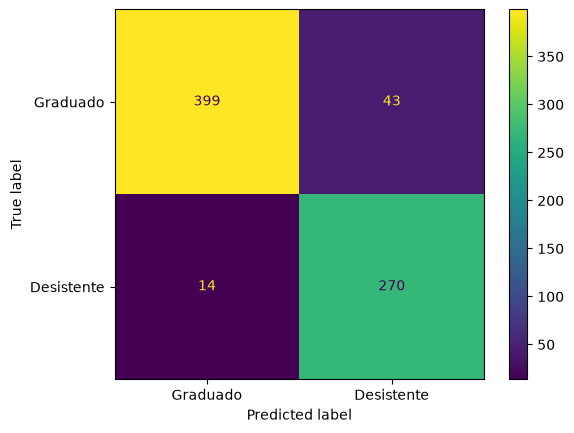

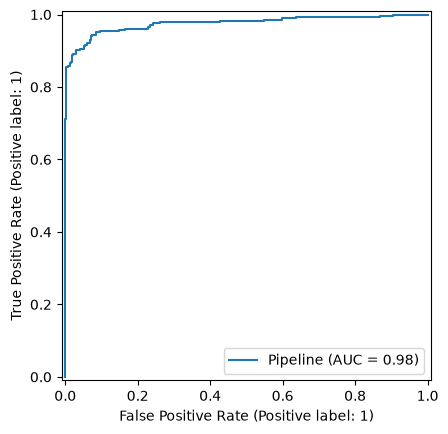

In [24]:
img_dir = '../docs/img'
os.makedirs(img_dir, exist_ok=True)

y_pred = pipeline_logregr_balanced.predict(X_test)
y_proba = pipeline_logregr_balanced.predict_proba(X_test)[:, 1]

print(f'Test F1: {f1_score(y_test, y_pred):.3f}')
print(f'Test ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')
print(classification_report(y_test, y_pred, target_names=['Graduado', 'Desistente']))

cm_display = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Graduado', 'Desistente'])
roc_display = RocCurveDisplay.from_estimator(pipeline_logregr_balanced, X_test, y_test)

cm_display.figure_.savefig(
    f'{img_dir}/confusion_matrix_logreg_balanced.png', dpi=150, bbox_inches='tight')
roc_display.figure_.savefig(
    f'{img_dir}/roc_curve_logreg_balanced.png', dpi=150, bbox_inches='tight')

# Extraindo o modelo via joblib

In [25]:
joblib.dump(pipeline_logregr_balanced,'../models/logistic_regression_balanced.joblib')

with mlflow.start_run(run_name='Logistic Regression (balanced) - Final Model'):
	mlflow.log_params(pipeline_logregr_balanced.named_steps['classifier'].get_params())
	mlflow.log_metric('holdout_f1', f1_score(y_test, y_pred))
	mlflow.log_metric('holdout_roc_auc', roc_auc_score(y_test, y_proba))
	mlflow.log_artifact(f'{img_dir}/confusion_matrix_logreg_balanced.png')
	mlflow.log_artifact(f'{img_dir}/roc_curve_logreg_balanced.png')
	mlflow.sklearn.log_model(pipeline_logregr_balanced, 'model', serialization_format='cloudpickle', registered_model_name='evasao-estudantil-logreg-balanced')

2026/08/24 23:31:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/24 23:31:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/24 23:31:31 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Successfully registered model 'evasao-estudantil-logreg-balanced'.
Created version '1' of model 'evasao-estudantil-logreg-balanced'.


# Rodando a avaliação do modelo final

In [26]:
df_enrolled_students = add_academic_performance_features(df_enrolled, numeric_cols)

X_enrolled = df_enrolled_students.drop(columns=['Target'])
y_enrolled = df_enrolled_students['Target']

In [27]:
y_proba = pipeline_logregr_balanced.predict_proba(X_enrolled)[:,1]

In [ ]:
df_risk = df_enrolled_students.copy()
df_risk['risk_score'] = y_proba

top_risk = df_risk.sort_values(by='risk_score', ascending=False).head(20)
top_risk[['Curso', 'approval_rate_sem1', 'approval_rate_sem2', 'MensalidadesEmDia', 'risk_score']]

,Curso,approval_rate_sem1,approval_rate_sem2,MensalidadesEmDia,risk_score
3077,Engenharia Informática,0.000,0.000,0,0.999998
854,Engenharia Informática,0.000,0.000,0,0.999997
2239,Enfermagem Veterinária,0.000,0.000,0,0.999982
142,Gestão,0.000,0.000,0,0.999972
89,Engenharia Informática,0.400,0.000,1,0.999970
...,...,...,...,...,...
643,Enfermagem,1.000,1.000,1,0.022136
278,Enfermagem,1.000,1.000,1,0.022076
2551,Design de Comunicação,1.000,1.000,1,0.021925
4087,Enfermagem,0.875,0.875,1,0.014905


In [33]:
top_risk.to_csv('../data/top_risk_students.csv', index=False)